In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import *

In [20]:
df = pd.read_csv('Loan_default.csv')

In [21]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [22]:
df['Education'].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

<h2>Data Preprocessing</h2>

In [23]:
df = df.drop('LoanID', axis=1)

In [24]:
Age_range = [15, 25, 35, 45, 55, 65, 70]
df['Age_group'] = pd.cut(df['Age'], bins=Age_range)
df = df.drop('Age', axis=1)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype   
---  ------          --------------   -----   
 0   Income          255347 non-null  int64   
 1   LoanAmount      255347 non-null  int64   
 2   CreditScore     255347 non-null  int64   
 3   MonthsEmployed  255347 non-null  int64   
 4   NumCreditLines  255347 non-null  int64   
 5   InterestRate    255347 non-null  float64 
 6   LoanTerm        255347 non-null  int64   
 7   DTIRatio        255347 non-null  float64 
 8   Education       255347 non-null  str     
 9   EmploymentType  255347 non-null  str     
 10  MaritalStatus   255347 non-null  str     
 11  HasMortgage     255347 non-null  str     
 12  HasDependents   255347 non-null  str     
 13  LoanPurpose     255347 non-null  str     
 14  HasCoSigner     255347 non-null  str     
 15  Default         255347 non-null  int64   
 16  Age_group       255347 non-null  category
dtypes:

In [26]:
col_list = list(df.columns)
col_list.remove('Default')

In [28]:
col_list

['Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Age_group']

In [29]:
le = LabelEncoder()
st = StandardScaler()
for i in col_list:
    if df[i].dtype == 'int64' or df[i].dtype == 'float64':
        df[i] = st.fit_transform(df[i].values.reshape(-1, 1))
    else:
        df[i] = le.fit_transform(df[i])


In [30]:
df.head(10)

,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Age_group
0,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,-1.335708,-1.342541,-1.225315,0.999973,0.999464,1.415354,0.999785,0,1.102564
1,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,0.451884,-1.342541,0.000101,-1.000027,-1.000537,1.415354,0.999785,0,1.753689
2,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,0.451884,1.342369,-1.225315,0.999973,0.999464,-1.416063,-1.000215,1,0.451438
3,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,-0.441912,-1.342541,0.000101,-1.000027,-1.000537,-0.708209,-1.000215,0,-0.850813
4,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,-1.335708,1.342369,-1.225315,-1.000027,0.999464,-1.416063,-1.000215,0,1.102564
5,0.200157,-0.524147,0.917133,-1.199134,-0.448549,1.390390,-0.708685,-1.733149,-0.441912,1.342369,1.225517,0.999973,-1.000537,-0.708209,0.999785,1,-1.501939
6,0.736307,0.697992,-0.914167,0.590533,-1.343791,0.846423,-1.415845,-1.473314,-1.335708,1.342369,1.225517,0.999973,-1.000537,0.707499,0.999785,0,-0.199688
7,1.137047,0.394296,-0.272268,0.215280,1.341937,-0.805067,1.412793,-0.304059,1.345680,-1.342541,0.000101,-1.000027,-1.000537,0.707499,0.999785,0,1.102564
8,-1.038071,-0.497199,1.590497,0.677130,-1.343791,1.574224,0.705634,-1.300091,-1.335708,0.447399,-1.225315,0.999973,-1.000537,-0.000355,-1.000215,1,-0.199688
9,1.290578,1.424765,-0.593217,1.571964,1.341937,-0.663425,0.705634,-0.737116,-0.441912,0.447399,0.000101,0.999973,-1.000537,1.415354,0.999785,0,-0.199688


In [31]:
X = df.drop('Default', axis=1)
y = df['Default']

<h3>Splitting the Data for Training & Testing</h3>

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
def model_accuracy(x,y):
    print('Accuracy : ', accuracy_score(x,y));
    print('Precision : ', precision_score(x,y));
    print('Recall : ', recall_score(x,y));
    print('F1 Score : ', f1_score(x,y));

In [34]:
models = {   
    'Logistic Regression' : LogisticRegression(),
    'Decision Tree' : DecisionTreeClassifier(),
    'Random Forest' : RandomForestClassifier(),
    'Naive Bayes' : GaussianNB(),
    'KNN' : KNeighborsClassifier()
}

for model in models.values():
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

for name, model in models.items():
    print(name)
    print('Test Data : ')
    model_accuracy(y_test, model.predict(X_test))
    print('Train Data : ')
    model_accuracy(y_train, model.predict(X_train))
    print('-----------------------------')

Logistic Regression
Test Data : 
Accuracy :  0.8857646367730566
Precision :  0.6137931034482759
Recall :  0.03016949152542373
F1 Score :  0.057512116316639744
Train Data : 
Accuracy :  0.8849013839051876
Precision :  0.6034334763948498
Recall :  0.02959626152486002
F1 Score :  0.05642507424351874
-----------------------------
Decision Tree
Test Data : 
Accuracy :  0.8030350499314666
Precision :  0.19699839720238962
Recall :  0.22915254237288135
F1 Score :  0.21186241479276033
Train Data : 
Accuracy :  1.0
Precision :  1.0
Recall :  1.0
F1 Score :  1.0
-----------------------------
Random Forest
Test Data : 
Accuracy :  0.886822009007245
Precision :  0.6345291479820628
Recall :  0.047966101694915254
F1 Score :  0.0891900409706902
Train Data : 
Accuracy :  0.9999804187451353
Precision :  1.0
Recall :  0.9998316002189197
F1 Score :  0.9999157930192413
-----------------------------
Naive Bayes
Test Data : 
Accuracy :  0.8855296651654592
Precision :  0.6928571428571428
Recall :  0.016440677

In [35]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [36]:
pred = lr.predict(X_test)

<h3>Comparison of Train and Test Data</h3>

In [37]:
compare = pd.DataFrame({'Actual' : y_test, 'Predicted' : pred})
compare['Error'] = compare['Actual'] - compare['Predicted']
print(compare)

        Actual  Predicted  Error
51139        0          0      0
71005        0          0      0
35684        0          0      0
174087       0          0      0
137952       0          0      0
...        ...        ...    ...
35991        0          0      0
69680        0          0      0
184743       0          0      0
209406       0          0      0
123164       0          0      0

[51070 rows x 3 columns]


<h3>Plotting Predicted and Test Data</h3>

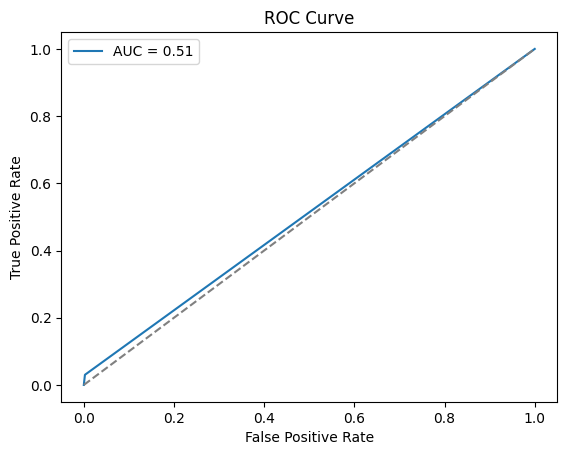

In [39]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, pred)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.2f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()